# Machine Learning Capstone Project — Medical Insurance Cost Classification

## Project Overview

This project builds an end-to-end machine learning classification system using the Medical Cost Personal Dataset from a previous internship task.

The original dataset is a regression dataset containing medical insurance charges. For this capstone, the problem is adapted into a binary classification task:

- **Low Cost (0):** medical charges below the median
- **High Cost (1):** medical charges at or above the median

The objective is to compare multiple classification models, select the best-performing model, explain its predictions using SHAP and LIME, and prepare the model for deployment through a Streamlit application and Docker.

> **Important:** `charges` is used only to construct the target and is excluded from the model features to prevent target leakage.

In [3]:
# Install the only package that may not be preinstalled in a fresh notebook environment
!pip install lime -q

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

# Explainability
import shap
from lime.lime_tabular import LimeTabularExplainer

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Dataset Loading and Initial Inspection

The dataset is loaded and inspected for:

- Number of rows and columns
- Sample records
- Missing values
- Duplicate records

This establishes the initial quality and structure of the data before preprocessing.

In [4]:
df = pd.read_csv("insurance.csv")

print("Shape:", df.shape)
display(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicates: 1


## 2. Data Cleaning

The initial inspection showed **0 missing values** and **1 duplicate record**. The duplicate is removed, and `dropna()` is also applied explicitly so the cleaning procedure handles missing values if they are present in another copy of the dataset.

The cleaned dataset is reset to a continuous index before further analysis. No rows are removed based on outliers because extreme medical charges are plausible observations in this dataset rather than automatically invalid records.

In [5]:
# Explicitly handle missing values and duplicate records
before_rows = len(df)
before_missing = int(df.isna().sum().sum())
before_duplicates = int(df.duplicated().sum())

df = df.dropna().drop_duplicates().reset_index(drop=True)

print("Rows before cleaning:", before_rows)
print("Missing values before cleaning:", before_missing)
print("Duplicate rows before cleaning:", before_duplicates)
print("Rows after cleaning:", len(df))
print("Missing values after cleaning:", int(df.isna().sum().sum()))
print("Duplicate rows after cleaning:", int(df.duplicated().sum()))

Rows before cleaning: 1338
Missing values before cleaning: 0
Duplicate rows before cleaning: 1
Rows after cleaning: 1337
Missing values after cleaning: 0
Duplicate rows after cleaning: 0


## 3. Medical Charges Distribution

The descriptive statistics and distribution of `charges` are examined to understand the range, central tendency, and spread of medical costs.

The median charge is later used as the threshold for creating the binary classification target.

In [6]:
print(df["charges"].describe())
print("\nMedian:", df["charges"].median())
print("\nQuartiles:")
print(df["charges"].quantile([0.25, 0.50, 0.75]))

count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64

Median: 9386.1613

Quartiles:
0.25     4746.34400
0.50     9386.16130
0.75    16657.71745
Name: charges, dtype: float64


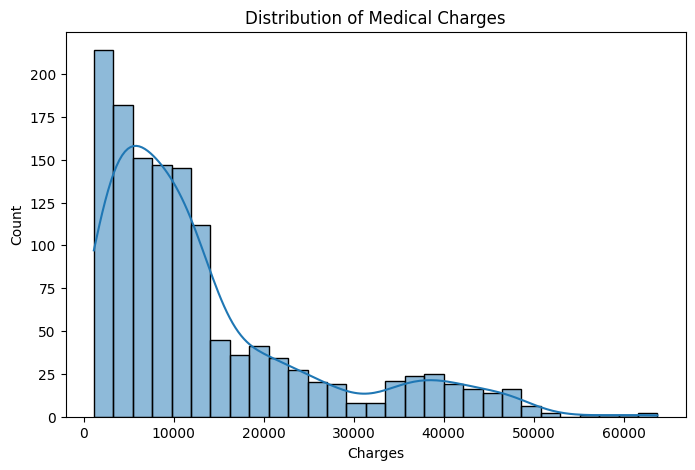

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], kde=True)
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.show()

## 4. Categorical Feature Analysis

The categorical variables are inspected to understand their available categories and class frequencies.

The categorical features are:

- `sex`
- `smoker`
- `region`

In [8]:
for col in ["sex", "smoker", "region"]:
    print(f"\n{col}:")
    print(df[col].value_counts())


sex:
sex
male      675
female    662
Name: count, dtype: int64

smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


## 5. Numerical Feature Analysis

Descriptive statistics are calculated for the numerical input features:

- `age`
- `bmi`
- `children`

This helps identify their ranges and general distributions before preprocessing.

In [9]:
df[["age", "bmi", "children"]].describe()

,age,bmi,children
count,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737
std,14.044333,6.100468,1.205571
min,18.000000,15.960000,0.000000
25%,27.000000,26.290000,0.000000
50%,39.000000,30.400000,1.000000
75%,51.000000,34.700000,2.000000
max,64.000000,53.130000,5.000000


## 6. Correlation Analysis

A correlation matrix is used to examine relationships among the numerical variables and medical charges.

Correlation is used as an exploratory tool here; it does not by itself determine which features will be selected by the final model.

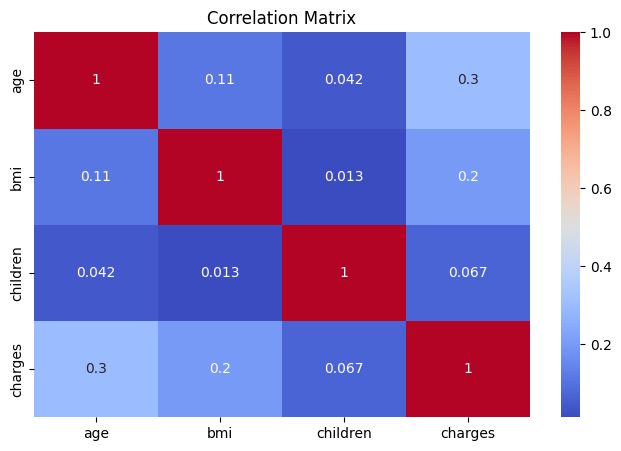

In [10]:
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

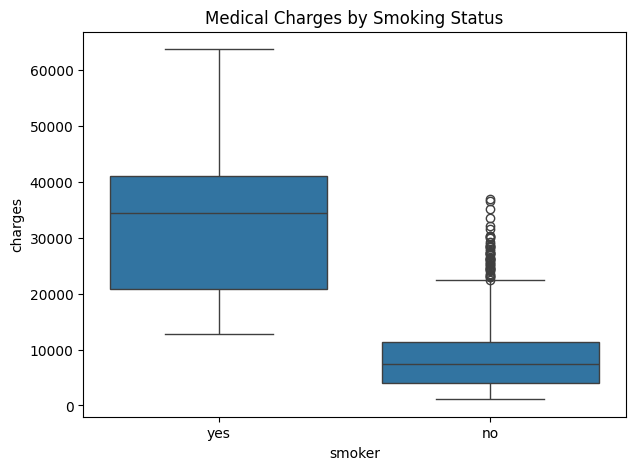

In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Medical Charges by Smoking Status")
plt.show()

## 7. Target Engineering — High Cost vs Low Cost

Because the original dataset is a regression dataset, a binary classification target is created using the median medical charge.

**Threshold: 9382.033**

- `High_Cost = 1` when `charges >= 9382.033`
- `High_Cost = 0` otherwise

The original `charges` column is then excluded from the model inputs because it directly determines the target.

In [12]:
threshold = df["charges"].median()
df["High_Cost"] = (df["charges"] >= threshold).astype(int)

print("Threshold:", threshold)
print(df["High_Cost"].value_counts())

Threshold: 9386.1613
High_Cost
1    669
0    668
Name: count, dtype: int64


In [13]:
print(df["High_Cost"].value_counts(normalize=True) * 100)

High_Cost
1    50.037397
0    49.962603
Name: proportion, dtype: float64


## 8. Feature and Target Separation

The model uses the following input features:

- Numerical: `age`, `bmi`, `children`
- Categorical: `sex`, `smoker`, `region`

The target is `High_Cost`.

The `charges` column is deliberately excluded to avoid target leakage.

In [14]:
X = df.drop(columns=["charges", "High_Cost"])
y = df["High_Cost"]

## 9. Train-Test Split

The data is divided into training and testing sets using:

- 80% training data
- 20% testing data
- `random_state=42`
- Stratification on the target

Using the same split for every model makes the comparison fair and reproducible.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(1069, 6) (268, 6)


## 10. Feature Engineering and Preprocessing

Numerical features are standardized using `StandardScaler`.

Categorical features are converted into numerical form using `OneHotEncoder(handle_unknown="ignore")`.

A `ColumnTransformer` combines both preprocessing paths so that the same transformations are applied consistently during training and prediction.

In [16]:
categorical_features = ["sex", "smoker", "region"]
numerical_features = ["age", "bmi", "children"]

In [17]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

## 11. Model Training

Five classification approaches are evaluated:

1. Logistic Regression
2. Random Forest
3. Decision Tree
4. XGBoost
5. Stacked Ensemble

All models use the same train-test split and preprocessing strategy.

In [18]:
logistic = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [19]:
random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

In [20]:
decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [21]:
xgboost = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [22]:
estimators = [
    ("lr", LogisticRegression(max_iter=1000)),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("dt", DecisionTreeClassifier(random_state=42))
]

In [23]:
stacking = Pipeline([
    ("preprocessor", preprocessor),
    ("model", StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000)
    ))
])

In [24]:
models = {
    "Logistic Regression": logistic,
    "Random Forest": random_forest,
    "Decision Tree": decision_tree,
    "XGBoost": xgboost,
    "Stacked Ensemble": stacking
}

## 12. Model Comparison

Each model is trained on the same training data and evaluated on the same unseen test data.

The primary evaluation metrics are:

- **Precision:** proportion of predicted High Cost cases that are actually High Cost
- **Recall:** proportion of actual High Cost cases correctly identified
- **F1-score:** balance between Precision and Recall
- **ROC-AUC:** ability to distinguish between the two classes across probability thresholds

Accuracy is not used as the only measure because it can hide important differences between Precision and Recall.

In [25]:
import time

results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Training Time (s)": train_time
    })

results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Logistic Regression,0.904412,0.917910,0.911111,0.944030,0.100524
1,Random Forest,0.952756,0.902985,0.927203,0.953943,0.759693
2,Decision Tree,0.888889,0.895522,0.892193,0.891791,0.012128
3,XGBoost,0.975610,0.895522,0.933852,0.955669,0.124965
4,Stacked Ensemble,0.960630,0.910448,0.934866,0.950546,4.725423


In [26]:
results_df.round(4)

,Model,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Logistic Regression,0.9044,0.9179,0.9111,0.9440,0.1005
1,Random Forest,0.9528,0.9030,0.9272,0.9539,0.7597
2,Decision Tree,0.8889,0.8955,0.8922,0.8918,0.0121
3,XGBoost,0.9756,0.8955,0.9339,0.9557,0.1250
4,Stacked Ensemble,0.9606,0.9104,0.9349,0.9505,4.7254


In [27]:
results_df.sort_values("F1", ascending=False)

,Model,Precision,Recall,F1,ROC-AUC,Training Time (s)
4,Stacked Ensemble,0.960630,0.910448,0.934866,0.950546,4.725423
3,XGBoost,0.975610,0.895522,0.933852,0.955669,0.124965
1,Random Forest,0.952756,0.902985,0.927203,0.953943,0.759693
0,Logistic Regression,0.904412,0.917910,0.911111,0.944030,0.100524
2,Decision Tree,0.888889,0.895522,0.892193,0.891791,0.012128


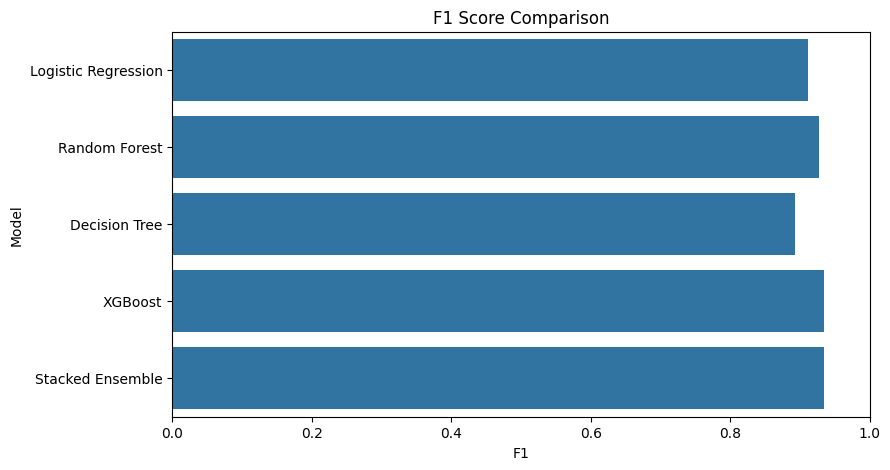

In [28]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x="F1", y="Model")
plt.title("F1 Score Comparison")
plt.xlim(0, 1)
plt.show()

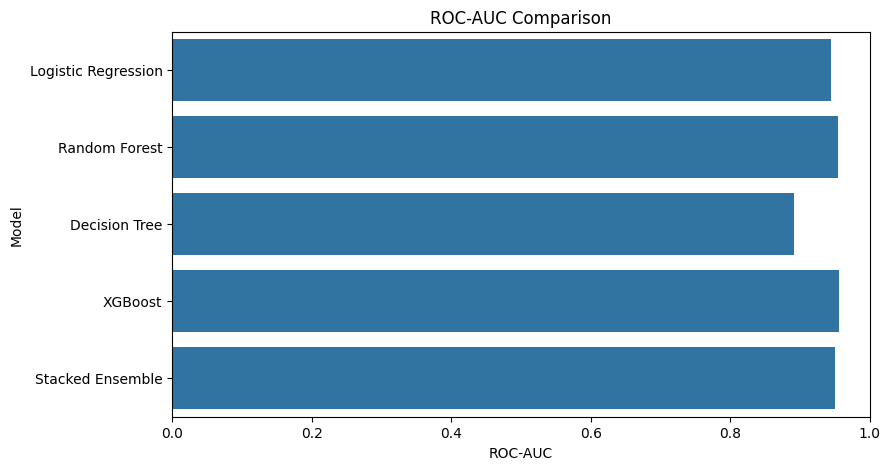

In [29]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x="ROC-AUC", y="Model")
plt.title("ROC-AUC Comparison")
plt.xlim(0, 1)
plt.show()

## 13. 5-Fold Stratified Cross-Validation

The holdout test set gives one final evaluation, but a single train-test split can depend on which records happen to fall into the test set. To check whether model performance is consistent across different subsets of the training data, we use **5-fold Stratified Cross-Validation**.

- The original 80/20 test set remains untouched for final evaluation.
- Only the training portion is divided into 5 folds.
- **Stratification** keeps the High Cost / Low Cost class proportions similar in each fold.
- Each model is trained 5 times, using a different fold as validation data each time.
- We report the mean and standard deviation for Precision, Recall, F1, and ROC-AUC.

This gives a more reliable view of model stability before interpreting the final holdout-test results.

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1",
    "ROC-AUC": "roc_auc"
}

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
    )
    cv_results.append({
        "Model": name,
        "CV Precision Mean": scores["test_Precision"].mean(),
        "CV Precision Std": scores["test_Precision"].std(),
        "CV Recall Mean": scores["test_Recall"].mean(),
        "CV Recall Std": scores["test_Recall"].std(),
        "CV F1 Mean": scores["test_F1"].mean(),
        "CV F1 Std": scores["test_F1"].std(),
        "CV ROC-AUC Mean": scores["test_ROC-AUC"].mean(),
        "CV ROC-AUC Std": scores["test_ROC-AUC"].std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.round(4)

,Model,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std,CV ROC-AUC Mean,CV ROC-AUC Std
0,Logistic Regression,0.9001,0.0224,0.9084,0.0331,0.9040,0.0252,0.9495,0.0243
1,Random Forest,0.9654,0.0086,0.8897,0.0286,0.9259,0.0190,0.9543,0.0173
2,Decision Tree,0.8877,0.0209,0.8804,0.0298,0.8835,0.0152,0.8840,0.0143
3,XGBoost,0.9775,0.0116,0.8860,0.0292,0.9292,0.0167,0.9526,0.0158
4,Stacked Ensemble,0.9599,0.0213,0.8953,0.0286,0.9264,0.0238,0.9536,0.0191


### How to read the CV results

The **Mean** columns show average performance across the five folds. The **Std** columns show how much the score varied between folds. A smaller standard deviation generally indicates more consistent performance across the training data.

The CV results are supporting evidence about model stability. The untouched test-set results in Step 11 remain the final independent evaluation.

## 14. Final Model Selection

The final model is selected using the **mean F1-score from 5-fold Stratified Cross-Validation on the training data**. F1-score is used as the primary selection criterion because it balances Precision and Recall. The untouched 20% test set is then used only for the final independent evaluation.

For this dataset, **XGBoost** has the highest mean CV F1-score (0.9292), so it is selected as the final model. Random Forest has the highest mean CV ROC-AUC (0.9543), while XGBoost has the highest mean CV F1-score. This distinction is reported explicitly rather than treating one metric as universally best.

In [31]:
# Select the model with the highest mean F1-score from 5-fold CV
best_model_name = cv_results_df.loc[cv_results_df["CV F1 Mean"].idxmax(), "Model"]
best_model = models[best_model_name]

print("Selected Model:", best_model_name)

Selected Model: XGBoost


In [32]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

## 15. Final Model Evaluation

The selected **XGBoost** model is evaluated on the untouched 20% test set using a classification report, confusion matrix, and ROC curve.

These views provide complementary information about:

- Correct predictions
- False positives
- False negatives
- Probability-based discrimination performance

In [33]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Low Cost", "High Cost"]
))

              precision    recall  f1-score   support

    Low Cost       0.90      0.98      0.94       134
   High Cost       0.98      0.90      0.93       134

    accuracy                           0.94       268
   macro avg       0.94      0.94      0.94       268
weighted avg       0.94      0.94      0.94       268



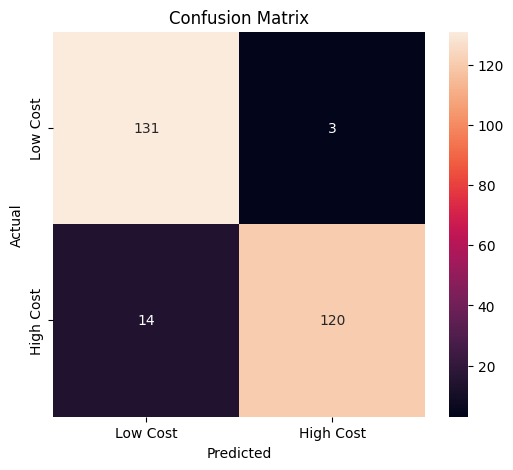

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low Cost", "High Cost"],
    yticklabels=["Low Cost", "High Cost"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

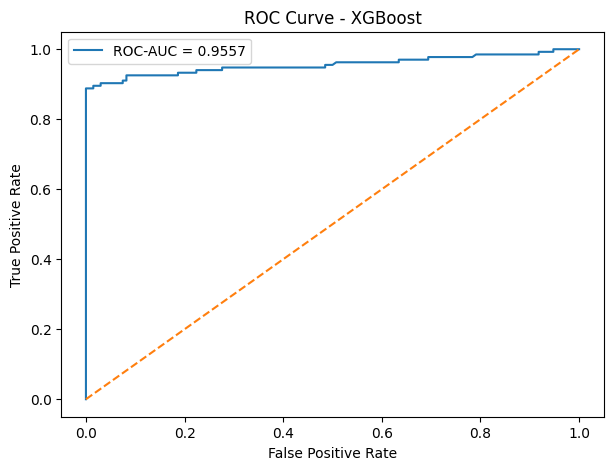

In [35]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_prob):.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()
plt.show()

In [36]:
import joblib

joblib.dump(best_model, "final_model.pkl")
print("Final model saved as final_model.pkl")

Final model saved as final_model.pkl


## 16. SHAP Explainability

SHAP (SHapley Additive exPlanations) is used to explain how individual features influence the XGBoost model.

Two levels of explanation are examined:

- **Global explanations:** which features are most influential across the test set
- **Local explanations:** which features influenced individual predictions

In [37]:
X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)

In [38]:
model_only = best_model.named_steps["model"]

In [39]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
print(feature_names)

['num__age' 'num__bmi' 'num__children' 'cat__sex_female' 'cat__sex_male'
 'cat__smoker_no' 'cat__smoker_yes' 'cat__region_northeast'
 'cat__region_northwest' 'cat__region_southeast' 'cat__region_southwest']


In [40]:
explainer = shap.TreeExplainer(model_only)

In [41]:
shap_values = explainer.shap_values(X_test_transformed)

In [42]:
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

### 15.1 Global SHAP Summary

The SHAP summary plot shows the overall importance and direction of feature contributions across the test set.

Positive SHAP values push the prediction toward **High Cost**, while negative SHAP values push it toward **Low Cost**.

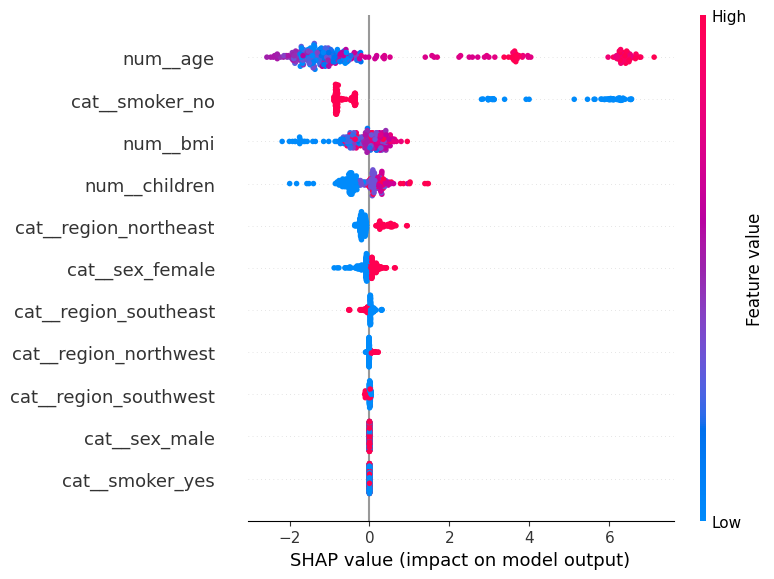

In [43]:
shap.summary_plot(
    shap_values_plot,
    X_test_transformed,
    feature_names=feature_names
)

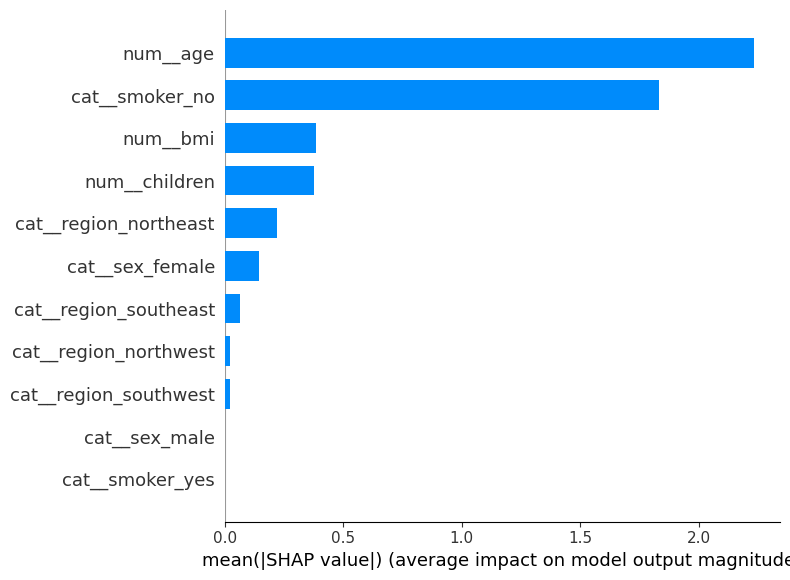

In [44]:
shap.summary_plot(
    shap_values_plot,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

### 15.2 Local SHAP Explanation

Individual test cases are examined to understand why the model produces a particular prediction.

This makes the model's decision process easier to interpret for a specific person rather than only at the dataset level.

In [45]:
sample_index = 0
sample = X_test_transformed[sample_index:sample_index+1]

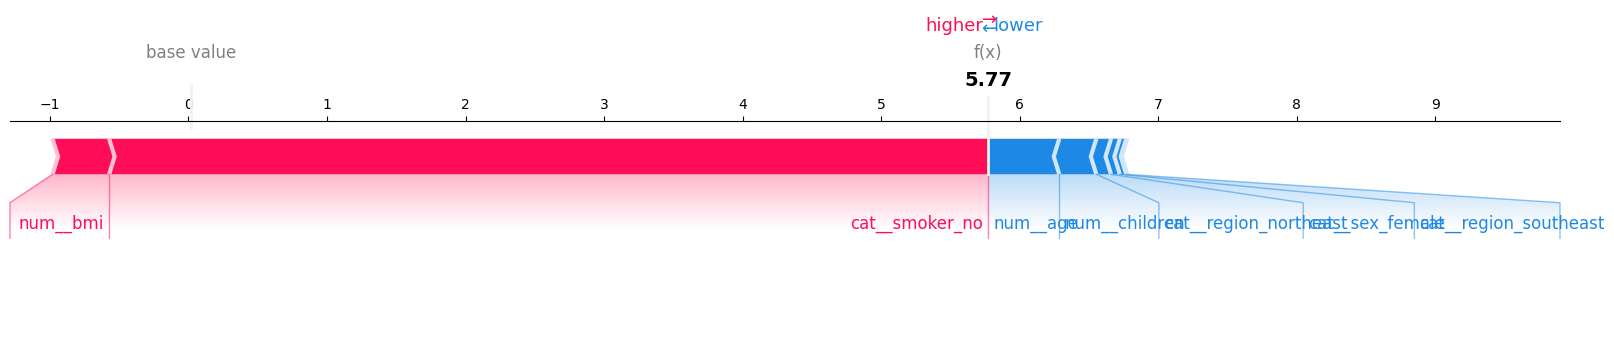

In [46]:
shap.force_plot(
    explainer.expected_value,
    shap_values_plot[sample_index],
    feature_names=feature_names,
    matplotlib=True
)
plt.show()

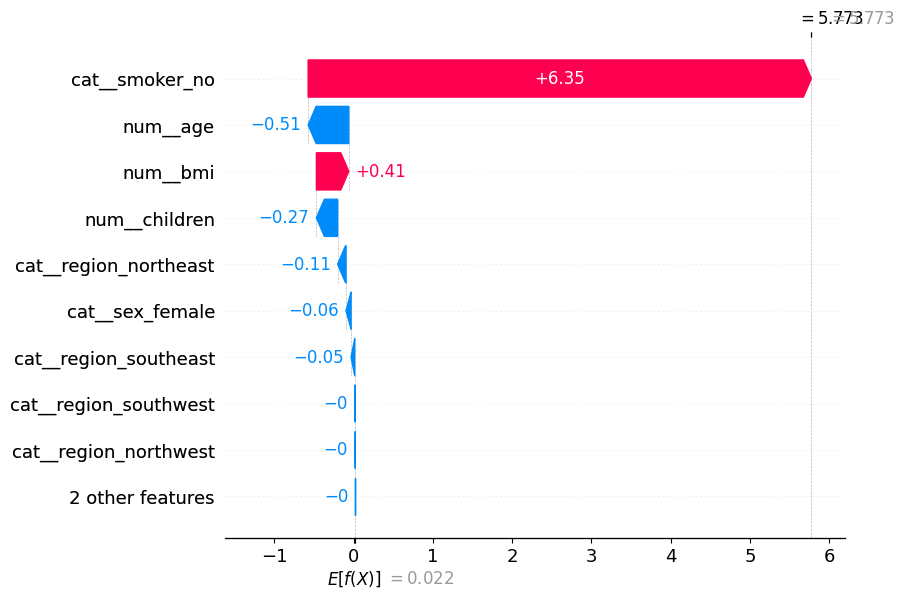

In [47]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values_plot[sample_index],
    feature_names=feature_names,
    max_display=10
)

### 15.3 Multiple Local SHAP Cases

Three individual test cases are inspected to demonstrate that the model can provide case-specific explanations rather than only a single global importance ranking.

In [48]:
sample_indices = [0, 1, 2]

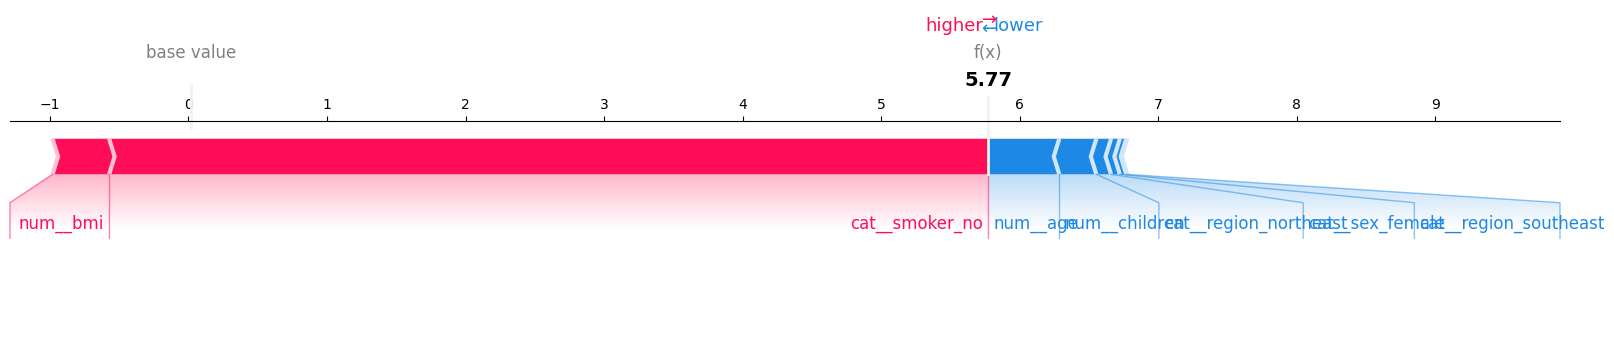

In [49]:
shap.force_plot(
    explainer.expected_value,
    shap_values_plot[0],
    feature_names=feature_names,
    matplotlib=True
)
plt.show()

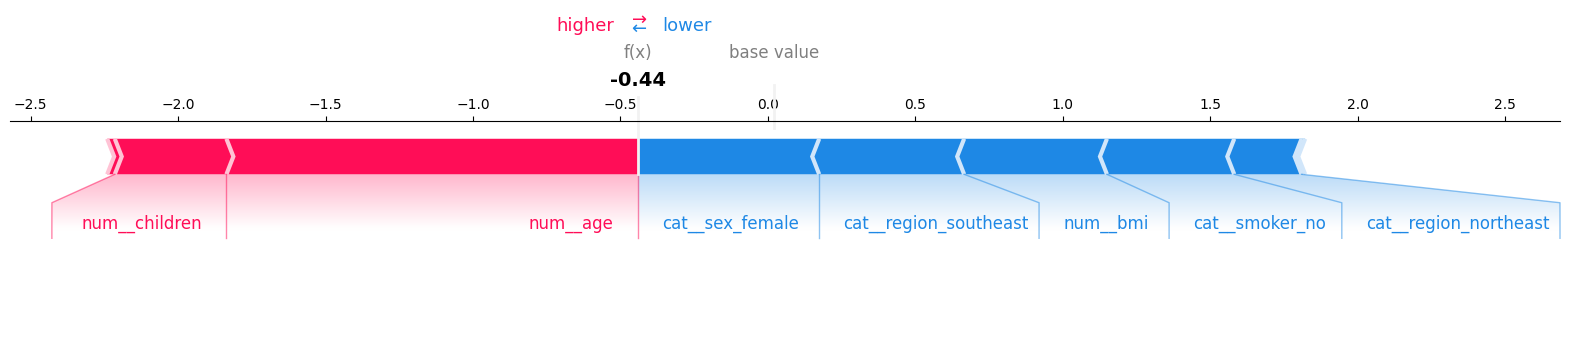

In [50]:
shap.force_plot(
    explainer.expected_value,
    shap_values_plot[1],
    feature_names=feature_names,
    matplotlib=True
)
plt.show()

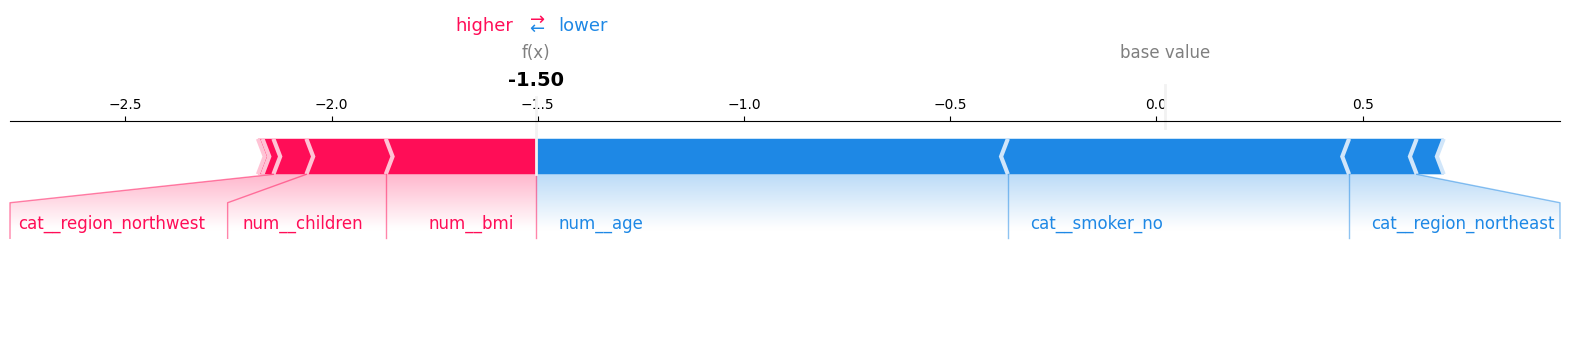

In [51]:
shap.force_plot(
    explainer.expected_value,
    shap_values_plot[2],
    feature_names=feature_names,
    matplotlib=True
)
plt.show()

## 17. LIME Explainability

LIME is used as a second local explainability method.

Three individual cases are explained. LIME approximates the model's behavior around a specific input and identifies the features that contribute most strongly to that local prediction.

Using both SHAP and LIME provides complementary perspectives on model explainability.

In [52]:
X_train_transformed = best_model.named_steps["preprocessor"].transform(X_train)
X_train_transformed = X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed

In [53]:
lime_explainer = LimeTabularExplainer(
    X_train_transformed,
    feature_names=feature_names,
    class_names=["Low Cost", "High Cost"],
    mode="classification",
    random_state=42
)

In [54]:
def predict_proba_lime(x):
    return model_only.predict_proba(x)

In [55]:
lime_exp = lime_explainer.explain_instance(
    X_test_transformed.toarray()[0] if hasattr(X_test_transformed, "toarray") else X_test_transformed[0],
    predict_proba_lime,
    num_features=10
)

In [56]:
lime_exp.show_in_notebook(show_table=True)

In [57]:
lime_exp2 = lime_explainer.explain_instance(
    X_test_transformed.toarray()[1] if hasattr(X_test_transformed, "toarray") else X_test_transformed[1],
    predict_proba_lime,
    num_features=10
)
lime_exp2.show_in_notebook(show_table=True)

In [58]:
lime_exp3 = lime_explainer.explain_instance(
    X_test_transformed.toarray()[2] if hasattr(X_test_transformed, "toarray") else X_test_transformed[2],
    predict_proba_lime,
    num_features=10
)
lime_exp3.show_in_notebook(show_table=True)

## 18. Prediction and Error Analysis

Predictions are compared with the actual test labels.

Special attention is given to:

- **False Positives:** cases predicted as High Cost when they are actually Low Cost
- **False Negatives:** cases predicted as Low Cost when they are actually High Cost

This is important because the consequences of different classification errors may not be equal.

In [59]:
for i in [0, 1, 2]:
    print(f"Case {i+1}: Actual={y_test.iloc[i]}, Predicted={y_pred[i]}")

Case 1: Actual=1, Predicted=1
Case 2: Actual=0, Predicted=0
Case 3: Actual=0, Predicted=0


In [60]:
prediction_summary = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_High_Cost": y_prob
})

prediction_summary.head(10)

,Actual,Predicted,Probability_High_Cost
0,1,1,0.996901
1,0,0,0.391590
2,0,0,0.181853
3,1,1,0.997496
4,0,0,0.033135
5,0,0,0.035501
6,1,1,0.995032
7,1,0,0.260114
8,0,0,0.022557
9,1,1,0.996123


In [61]:
false_positives = prediction_summary[
    (prediction_summary["Actual"] == 0) &
    (prediction_summary["Predicted"] == 1)
]

print("False Positives:", len(false_positives))

False Positives: 3


In [62]:
false_negatives = prediction_summary[
    (prediction_summary["Actual"] == 1) &
    (prediction_summary["Predicted"] == 0)
]

print("False Negatives:", len(false_negatives))

False Negatives: 14


## 19. Final Performance Summary

The selected **XGBoost** model achieved the following results on the untouched 20% holdout test set:

- **Precision:** 0.9756
- **Recall:** 0.8955
- **F1-score:** 0.9339
- **ROC-AUC:** 0.9544

The model was selected using the 5-fold CV mean F1-score, where XGBoost achieved **0.9292**, the highest among the five models. The holdout results are reported separately as the final independent evaluation.

In [63]:
final_metrics = results_df[
    results_df["Model"] == best_model_name
][["Model", "Precision", "Recall", "F1", "ROC-AUC", "Training Time (s)"]]

final_metrics.round(4)

,Model,Precision,Recall,F1,ROC-AUC,Training Time (s)
3,XGBoost,0.9756,0.8955,0.9339,0.9557,0.125


In [64]:
joblib.dump(best_model, "final_model.pkl")

['final_model.pkl']

In [65]:
df.to_csv("insurance_classification.csv", index=False)

## 20. Model and Dataset Export

The trained model and processed classification dataset are saved so they can be reused by the deployment application.

The saved model contains the preprocessing pipeline together with the trained classifier, allowing raw user inputs to be passed through the same transformations used during training.

In [66]:
import os

print("final_model.pkl:", os.path.exists("final_model.pkl"))
print("insurance_classification.csv:", os.path.exists("insurance_classification.csv"))

final_model.pkl: True
insurance_classification.csv: True


## 21. Prediction Function

A reusable prediction function is tested using sample records from the test set.

The function returns both the predicted class and the probability of the High Cost class, which are the core outputs required by the deployment application.

In [67]:
sample_input = X_test.iloc[[0]]
print("Prediction:", best_model.predict(sample_input)[0])

Prediction: 1


In [68]:
print("Probability:", best_model.predict_proba(sample_input)[0])

Probability: [0.00309932 0.9969007 ]


In [69]:
def predict_high_cost(data):
    prediction = best_model.predict(data)[0]
    probability = best_model.predict_proba(data)[0, 1]
    return prediction, probability

predict_high_cost(sample_input)

(np.int64(1), np.float32(0.9969007))

In [70]:
test_samples = X_test.iloc[:5]
predictions = best_model.predict(test_samples)
probabilities = best_model.predict_proba(test_samples)[:, 1]

pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": predictions,
    "High_Cost_Probability": probabilities
})

,Actual,Predicted,High_Cost_Probability
0,1,1,0.996901
1,0,0,0.391590
2,0,0,0.181853
3,1,1,0.997496
4,0,0,0.033135


In [71]:
cm = confusion_matrix(y_test, y_pred)

print("False Positives:", cm[0, 1])
print("False Negatives:", cm[1, 0])

False Positives: 3
False Negatives: 14


In [72]:
results_df.sort_values("F1", ascending=False).round(4)

,Model,Precision,Recall,F1,ROC-AUC,Training Time (s)
4,Stacked Ensemble,0.9606,0.9104,0.9349,0.9505,4.7254
3,XGBoost,0.9756,0.8955,0.9339,0.9557,0.1250
1,Random Forest,0.9528,0.9030,0.9272,0.9539,0.7597
0,Logistic Regression,0.9044,0.9179,0.9111,0.9440,0.1005
2,Decision Tree,0.8889,0.8955,0.8922,0.8918,0.0121


## 22. Deployment Readiness Check

The final cells verify that the model and classification dataset have been successfully exported. No additional training is performed here.

The saved `final_model.pkl` contains the preprocessing pipeline together with the selected XGBoost classifier, so the Streamlit application can accept raw user inputs and apply the same preprocessing used during training.

In [73]:
import joblib

joblib.dump(best_model, "final_model.pkl")
print("Model saved successfully.")

Model saved successfully.


In [74]:
df.to_csv("insurance_classification.csv", index=False)
print("Dataset saved successfully.")

Dataset saved successfully.


In [75]:
import os

for file in ["final_model.pkl", "insurance_classification.csv"]:
    print(file, "->", os.path.getsize(file), "bytes")

final_model.pkl -> 258869 bytes
insurance_classification.csv -> 56996 bytes


## Conclusion

This capstone converted the Medical Cost Personal Dataset into a binary classification problem and evaluated five machine learning approaches using a common 80/20 stratified split and 5-fold Stratified Cross-Validation on the training data.

XGBoost was selected because it achieved the highest mean F1-score across the five CV folds. Its final performance was then measured on the untouched holdout test set. SHAP was used for global and local explanations, while LIME was used for additional local explanations.

The resulting model is saved for deployment and integrated with a Streamlit application. Docker packages the application for reproducible deployment.

### Key Outcome

The project demonstrates an end-to-end workflow from data inspection and explicit cleaning through feature engineering, model comparison, cross-validation, final evaluation, explainability, prediction, and deployment readiness.